In [1]:
from PIL import Image
from transformers import Qwen2VLForConditionalGeneration, Qwen2VLImageProcessor, AutoProcessor
from qwen_vl_utils import process_vision_info
import gradio as gr
import zipfile
import os
import numpy as np
import random
import shutil
import pandas as pd
import cv2
from qwen import read_blue_channel
import yaml
from qwen import read_red_channel, read_green_channel, read_blue_channel, extract_zip_path, generate_random_sample, red_green_channel
from langchain.prompts import PromptTemplate
from langchain.chat_models import ChatOpenAI
from langchain.chains import LLMChain
import json
import torch


c:\Users\archi\anaconda3\envs\asid\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\archi\anaconda3\envs\asid\lib\site-packages\torchvision\datapoints\__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
c:\Users\archi\anaconda3\envs\asid\lib\site-packages\torchvision\transfo

## Load Data

In [2]:
HOME = os.path.expanduser('~') + "\\ecdna-analysis"
config_path = os.path.join(HOME, "config.yaml")

config = open(config_path)
var = yaml.load(config, Loader=yaml.FullLoader)['qwen']

zip_file_path = os.path.join(HOME, var['zipfile_path'])
test_folder_name = var['test_folder_name']
test_extract_folder = os.path.join(HOME, var['test_extract_folder'])
train_folder_name = var['train_folder_name']
train_extract_folder = os.path.join(HOME, var['train_extract_folder'])

extract_zip_path(zip_file_path, train_folder_name, train_extract_folder)
extract_zip_path(zip_file_path, test_folder_name, test_extract_folder)

sample_size = var['sample_size']
input_folder = os.path.join(test_extract_folder , f'ecSeg_dataset\\{test_folder_name}')
output_folder = os.path.join(HOME, var['sampled'] )

test_images = os.path.join(test_extract_folder , f'ecSeg_dataset\\{test_folder_name}')
train_images = os.path.join(train_extract_folder , f'ecSeg_dataset\\{train_folder_name}')

## Model Initialization

In [3]:
# Initialize the tokenizer and the model name (using the Qwen2-VL 2B-Instruct model)
model_name = "Qwen/Qwen2-VL-2B-Instruct"
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_name, torch_dtype="auto", device_map="auto"
)
processor = AutoProcessor.from_pretrained(model_name)
image_processor = Qwen2VLImageProcessor.from_pretrained(model_name)

`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46
Loading checkpoint shards: 100%|██████████| 2/2 [00:08<00:00,  4.49s/it]


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model = model.to(device)
model.get_parameter

cuda


<bound method Module.get_parameter of Qwen2VLForConditionalGeneration(
  (visual): Qwen2VisionTransformerPretrainedModel(
    (patch_embed): PatchEmbed(
      (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
    )
    (rotary_pos_emb): VisionRotaryEmbedding()
    (blocks): ModuleList(
      (0-31): 32 x Qwen2VLVisionBlock(
        (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (attn): VisionAttention(
          (qkv): Linear(in_features=1280, out_features=3840, bias=True)
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (mlp): VisionMlp(
          (fc1): Linear(in_features=1280, out_features=5120, bias=True)
          (act): QuickGELUActivation()
          (fc2): Linear(in_features=5120, out_features=1280, bias=True)
        )
      )
    )
    (merger): PatchMerger(
      (ln_q): LayerNorm((1280,), eps=1e-06, element

# Generating Results

In [5]:
# Load train data into a df
train_df = pd.read_csv(HOME + '\\train_images_counts.csv')
train_df

,image,num_nuclei,num_chromosomes,num_ecDNA
0,2343.tif,1,0,0
1,2344.tif,2,0,0
2,2345.tif,0,5,0
3,2346.tif,0,18,0
4,2347.tif,1,6,1
...,...,...,...,...
4755,9653.tif,0,2,2
4756,9655.tif,2,0,0
4757,9657.tif,1,0,0
4758,9658.tif,2,0,0


In [6]:
# Load test data into a df
test_df = pd.read_csv(HOME + '\\test_images_counts.csv')
test_df

,image,num_nuclei,num_chromosomes,num_ecDNA
0,0.tif,2,1,1
1,1.tif,4,1,3
2,10.tif,1,6,2
3,1000.tif,3,4,2
4,1001.tif,1,0,0
...,...,...,...,...
1184,992.tif,0,6,0
1185,993.tif,0,18,3
1186,994.tif,0,26,0
1187,995.tif,0,17,5


# Experiments


In [8]:
# Define system message
system_message = '''
    You are a pathologist analyzing metaphase cell images. These images contain three main structures: ecDNA, nuclei, and chromosomes. Your goal is to focus on connected component analysis in the image.
'''
final_question = '''
    How many ecDNA are in the image? Return an integer number in JSON format.
'''
# Number of N-shot trials
n_shots = [0, 1, 2, 3]

# Temperatures for temperature adjustment experiment
temperatures = [0.2, 0.3, 0.5, 0.8, 0.9]

# Number of times same question will be asked for aggregated results experiment
num_trials = 5
questions_list = [
    'Describe this image.',
    'How many connected components do you see?',
    'Describe the ecDNA patterns in this image.'
]

# Images for N-shot learning
n_shot_images = [
    (1, Image.open(os.path.join(train_images, '2347.tif'))),
    (7, Image.open(os.path.join(train_images, '2372.tif'))),
    (19, Image.open(os.path.join(train_images, '2573.tif'))),
    (68, Image.open(os.path.join(train_images, '3274.tif'))),
    (129, Image.open(os.path.join(train_images, '4714.tif'))),
    (0, Image.open(os.path.join(train_images, '2343.tif'))),
]

n_shot_images_chromosomes = [
    (0, Image.open(os.path.join(train_images, '3395.tif'))),
    (14, Image.open(os.path.join(train_images, '3410.tif'))),
    (31, Image.open(os.path.join(train_images, '3430.tif'))),
    (12, Image.open(os.path.join(train_images, '3591.tif'))),
    (25, Image.open(os.path.join(train_images, '3830.tif'))),
    (1, Image.open(os.path.join(train_images, '3442.tif'))),
]

n_shot_images_nuclei = [
    (0, Image.open(os.path.join(train_images, '3786.tif'))),
    (22, Image.open(os.path.join(train_images, '4858.tif'))),
    (3, Image.open(os.path.join(train_images, '4868.tif'))),
    (4, Image.open(os.path.join(train_images, '3707.tif'))),
    (14, Image.open(os.path.join(train_images, '4875.tif'))),
    (7, Image.open(os.path.join(train_images, '4859.tif'))),
]

# 0-shot learning questions
context_messages = [
    'You are a pathologist analyzing metaphase cell images.',
    'You are a perfect AI tool identifying the count of ecDNA.',
    'You are a researcher identifying the location of ecDNA.'
]

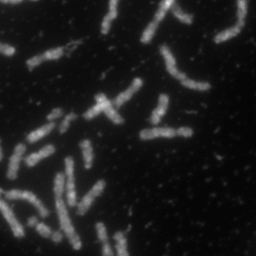

In [9]:
read_blue_channel(os.path.join(train_images, '4714.tif'))

In [10]:
def generate_result(conversation, top_k=10, top_p=0.95, temperature=0.7, repetition_penalty=1.05, do_sample=True):
    '''
        This function generates output for the Qwen2 model given a conversation.
        
        Input:

        Returns:

    '''
    text = processor.apply_chat_template(
            conversation, tokenize=False, add_generation_prompt=True, add_vision_id=True
        )

    inputs = processor(
            text=[text],
            padding=True,
            return_tensors="pt",
    )

    inputs = inputs.to(device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=128,
        top_k=top_k,
        top_p=top_p,
        temperature=temperature,
        repetition_penalty=repetition_penalty,
        do_sample=do_sample
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]
    
    return output_text

In [11]:
def qwen2_6_shot(
    image,
    n_shot_images,
    system_message = '',
    root_folder = test_images,
    top_k = 5,
    top_p = 0.99,
    do_sample = True,
    repetition_penalty = 1.1,
):
    '''
        Run an N-shot experiment.
        Input:
            image: test image
            n_shots: number of N-shot learning experiments (must be a list)
        Output:
            list of responses for each experiment
    '''

    n = len(n_shot_images)
    img_path = os.path.join(root_folder, image)
    test_image = read_blue_channel(img_path)

    # Sample images from train dataframe
    conversation = [
        {
            'role': 'user',
            'content': f'{system_message} ecDNA are circular structures in cell images.'
        }
    ]
    for i in range(n):
        count, image = n_shot_images[i]
        conversation.append({
            'role': 'user',
            'content': [
                {'type': 'image', 'image': image},
                {'type': 'text', 'text': f"A cell image containing {count} ecDNA."}
            ]
        })
            
    prompt = PromptTemplate(
        template = 
        '''
            
            Give the count of ecDNA in the image. Your answer must be a multiple of 10.
        '''
    )
    
    formatted_prompt = prompt.format(final_question=final_question)

    conversation.append({
        'role': 'user',
        'content': [
            {'type': 'image', 'image': test_image},
            {'type': 'text', 'text': formatted_prompt}
        ]
    })

    output_text = generate_result(
        conversation,
        top_k=top_k,
        top_p=top_p,
        repetition_penalty=repetition_penalty,
        do_sample=do_sample
    )
    
    return output_text

In [12]:
test_df[test_df.index == 1188]

,image,num_nuclei,num_chromosomes,num_ecDNA
1188,998.tif,0,3,0


In [13]:
qwen2_6_shot(test_df['image'].iloc[1188], n_shot_images, system_message=system_message)

'129'

In [14]:
# test_copy = test_df.copy()
# test_copy['6_shot'] = test_copy['image'].apply(lambda x: qwen2_6_shot(x, n_shot_images, system_message=system_message))
# test_copy.to_csv(HOME + '\\qwen\\experiment_6_shot.csv')

In [15]:
def qwen2_6_shot_chromosomes(
    image,
    n_shot_images_chromosomes,
    system_message = '',
    root_folder = test_images,
    top_k = 5,
    top_p = 0.99,
    do_sample = True,
    repetition_penalty = 1.1,
):
    '''
        Run an N-shot experiment.
        Input:
            image: test image
            n_shots: number of N-shot learning experiments (must be a list)
        Output:
            list of responses for each experiment
    '''

    n = len(n_shot_images_chromosomes)
    img_path = os.path.join(root_folder, image)
    test_image = read_blue_channel(img_path)

    # Sample images from train dataframe
    conversation = [
        {
            'role': 'user',
            'content': f'{system_message} chromosomes are X-shaped structures in cell images.'
        }
    ]
    for i in range(n):
        count, image = n_shot_images_chromosomes[i]
        conversation.append({
            'role': 'user',
            'content': [
                {'type': 'image', 'image': image},
                {'type': 'text', 'text': f"A cell image containing {count} chromosomes."}
            ]
        })
            
    prompt = PromptTemplate(
        template = 
        '''
            
            How many chromosomes are in the image? Return a single number as your answer in JSON format.
        '''
    )
    
    formatted_prompt = prompt.format()

    conversation.append({
        'role': 'user',
        'content': [
            {'type': 'image', 'image': test_image},
            {'type': 'text', 'text': formatted_prompt}
        ]
    })

    output_text = generate_result(
        conversation,
        top_k=top_k,
        top_p=top_p,
        repetition_penalty=repetition_penalty,
        do_sample=do_sample
    )
    
    return output_text

In [16]:
test_df[test_df.index == 250]

,image,num_nuclei,num_chromosomes,num_ecDNA
250,153.tif,0,17,55


In [18]:
test_copy = test_df.copy()
test_copy['6_shot_chromosomes'] = test_copy['image'].apply(lambda x: qwen2_6_shot_chromosomes(x, n_shot_images_chromosomes, system_message=system_message))
test_copy.to_csv(HOME + '\\qwen\\experiment_6_shot_chromosomes.csv')

In [19]:
def qwen2_6_shot_nuclei(
    image,
    n_shot_images_nuclei,
    system_message = '',
    root_folder = test_images,
    top_k = 5,
    top_p = 0.99,
    do_sample = True,
    repetition_penalty = 1.1,
):
    '''
        Run an N-shot experiment.
        Input:
            image: test image
            n_shots: number of N-shot learning experiments (must be a list)
        Output:
            list of responses for each experiment
    '''

    n = len(n_shot_images_nuclei)
    img_path = os.path.join(root_folder, image)
    test_image = read_blue_channel(img_path)

    # Sample images from train dataframe
    conversation = [
        {
            'role': 'user',
            'content': f'{system_message} nuclei are large circular structures in cell images.'
        }
    ]
    for i in range(n):
        count, image = n_shot_images_nuclei[i]
        conversation.append({
            'role': 'user',
            'content': [
                {'type': 'image', 'image': image},
                {'type': 'text', 'text': f"A cell image containing {count} nuclei."}
            ]
        })
            
    prompt = PromptTemplate(
        template = 
        '''
            
            How many nuclei are in the image? Return a single number as your answer in JSON format.
        '''
    )
    
    formatted_prompt = prompt.format()

    conversation.append({
        'role': 'user',
        'content': [
            {'type': 'image', 'image': test_image},
            {'type': 'text', 'text': formatted_prompt}
        ]
    })

    output_text = generate_result(
        conversation,
        top_k=top_k,
        top_p=top_p,
        repetition_penalty=repetition_penalty,
        do_sample=do_sample
    )
    
    return output_text

In [20]:
test_copy = test_df.copy()
test_copy['6_shot_nuclei'] = test_copy['image'].apply(lambda x: qwen2_6_shot_chromosomes(x, n_shot_images_nuclei, system_message=system_message))
test_copy.to_csv(HOME + '\\qwen\\experiment_6_shot_nuclei.csv')

### N-Shot Learning

In [ ]:
def qwen2_n_shot(
    image,
    n_shot_images,
    system_message = '',
    root_folder = test_images,
    top_k = 15,
    top_p = 0.95,
    do_sample = True,
    repetition_penalty = 1.05,
):
    '''
        Run an N-shot experiment.
        Input:
            image: test image
            n_shots: number of N-shot learning experiments (must be a list)
        Output:
            list of responses for each experiment
    '''

    n = len(n_shot_images)
    img_path = os.path.join(root_folder, image)
    test_image = Image.open(img_path)

    # Sample images from train dataframe
    result = []

    for i in range(0, n+1):
        conversation = [
                {
                    'role': 'user',
                    'content': f'{system_message} ecDNA are circular structures in cell images.'
                }
        ]
        if i != 0:
            for j in range(i):
                count, image = n_shot_images[j]
                conversation.append({
                    'role': 'user',
                    'content': [
                        {'type': 'image', 'image': image},
                        {'type': 'text', 'text': f"This is a cell image containing {count} ecDNA"}
                    ]
                })

                conversation.append({
                    'role': 'assistant',
                    'content': 'Thank you for the information. I see that the image has {count} ecDNA.'
                })
            
        prompt = PromptTemplate(
            template = 
            '''
                {final_question}
            '''
        )
        
        formatted_prompt = prompt.format(final_question=final_question)

        conversation.append({
            'role': 'user',
            'content': [
                {'type': 'image', 'image': test_image},
                {'type': 'text', 'text': formatted_prompt}
            ]
        })

        output_text = generate_result(
            conversation,
            top_k=top_k,
            top_p=top_p,
            repetition_penalty=repetition_penalty,
            do_sample=do_sample
        )

        result.append(output_text)
    
    return conversation


In [ ]:
# Test output
qwen2_n_shot(test_df['image'].iloc[122], n_shot_images, system_message=system_message)

In [ ]:
# test_copy = test_df.copy()
# test_copy['n_shot'] = test_copy['image'].apply(lambda x: qwen2_n_shot(x, n_shot_images, system_message=system_message))
# test_copy.to_csv(HOME + '\\qwen\\experiment_n_shot_new.csv')

### Multi-Layered Prompts

In [ ]:
def qwen2_multi_layer(
        image,
        questions_list,
        root_folder = test_images,
        system_message=system_message,
        top_k = 10,
        top_p = 0.95,
        do_sample = True,
        repetition_penalty = 1.05
):
    '''
        This function runs a multi-layered prompt experiment.
        Inputs:
        
        Returns:

    '''
    img_path = os.path.join(root_folder, image)
    test_image = Image.open(img_path)

    prompt = PromptTemplate(
            template = 
            '''
                {final_question}
            '''
        )
    
    formatted_prompt = prompt.format(final_question=final_question)
    # Sample images from train dataframe

    conversation = [
        {
            'role': 'user',
            'content': f'{system_message} ecDNA are circular structures in cell images.'
        },
    ]

    for question in questions_list:
        conversation.append({
            'role': 'user',
            'content': [
                {'type': 'image', 'image': test_image},
                {'type': 'text', 'text': question}
            ]
        })

        output_text = generate_result(
            conversation,
            top_k=top_k,
            top_p=top_p,
            repetition_penalty=repetition_penalty,
            do_sample=do_sample
        )

        conversation.append({
            'role': 'assistant',
            'content': output_text
        })

    # Generate final output result
    conversation.append({
            'role': 'user',
            'content': [
                {'type': 'image', 'image': test_image},
                {'type': 'text', 'text': formatted_prompt}
            ]
    })

    output_text = generate_result(
        conversation,
        top_k=top_k,
        top_p=top_p,
        repetition_penalty=repetition_penalty,
        do_sample=do_sample
    )

    return output_text

In [ ]:
# Test output
qwen2_multi_layer(test_df['image'].iloc[0], questions_list, system_message=system_message)

In [ ]:
# test_copy = test_df.copy()
# test_copy['multi_layer'] = test_copy['image'].apply(lambda x: qwen2_multi_layer(x, questions_list, system_message=system_message))
# test_copy.to_csv(HOME + '\\qwen\\experiment_multi_layer.csv')

### Aggregating Over Multiple Trials

In [ ]:
def qwen2_agg_results(
        image,
        num_trials,
        system_message = '',
        root_folder = test_images,
        top_k = 10,
        top_p = 0.95,
        do_sample = True,
        repetition_penalty = 1.05
):
    img_path = os.path.join(root_folder, image)
    test_image = Image.open(img_path)

    prompt = PromptTemplate(
            template = 
            '''
                {final_question}
            '''
        )
    
    formatted_prompt = prompt.format(final_question=final_question)
    # Sample images from train dataframe
    result = []

    conversation = [
        {
            'role': 'user',
            'content': f'{system_message} ecDNA are circular structures in cell images.'
        },
        {
            'role': 'user',
            'content': [
                {'type': 'image', 'image': test_image},
                {'type': 'text', 'text': formatted_prompt}
            ]
        }
    ]

    for i in range(num_trials):
        output_text = generate_result(
            conversation,
            top_k=top_k,
            top_p=top_p,
            repetition_penalty=repetition_penalty,
            do_sample=do_sample
        )

        result.append(output_text)

    return result

In [ ]:
# Test output
qwen2_agg_results(test_df['image'].iloc[1188], num_trials, system_message=system_message)

In [ ]:
# test_copy = test_df.copy()
# test_copy['agg_results'] = test_copy['image'].apply(lambda x: qwen2_agg_results(x, num_trials, system_message=system_message))
# test_copy.to_csv(HOME + '\\qwen\\experiment_agg_results.csv')

### Temperature Adjustment

In [ ]:
def qwen2_temp_adj(
    image,
    temperatures,
    system_message = '',
    root_folder = test_images,
    top_k = 10,
    top_p = 0.8,
    do_sample = True,
    repetition_penalty = 1.05
):
    '''
        Run an N-shot experiment.
        Input:
            image: test image
            n_shots: number of N-shot learning experiments (must be a list)
        Output:
        list of responses for each experiment
    '''
    img_path = os.path.join(root_folder, image)
    test_image = Image.open(img_path)

    # Sample images from train dataframe
    result = []
    for temp in temperatures:

        conversation = [
            {
                'role': 'user',
                'content': f'{system_message} ecDNA are circular structures in cell images.'
            }
        ]

        prompt = PromptTemplate(
            template = 
            '''
                {final_question}
            '''
        )
        
        formatted_prompt = prompt.format(final_question=final_question)

        conversation.append({
            'role': 'user',
            'content': [
                {'type': 'image', 'image': test_image},
                {'type': 'text', 'text': formatted_prompt}
            ]
        })

        output_text = generate_result(
            conversation,
            top_k=top_k,
            top_p=top_p,
            temperature=temp,
            repetition_penalty=repetition_penalty,
            do_sample=do_sample
        )

        result.append(output_text)
    
    return result


In [ ]:
# Test output
qwen2_temp_adj(test_df['image'].iloc[1188], temperatures, system_message=system_message)

In [ ]:
# test_copy = test_df.copy()
# test_copy['temp_adj'] = test_copy['image'].apply(lambda x: qwen2_temp_adj(x, temperatures, system_message=system_message))
# test_copy.to_csv(HOME + '\\qwen\\experiment_temp_adj.csv')

# Context Questions

In [ ]:
def qwen2_context_qs(
    image,
    context_messages,
    root_folder = test_images,
    top_k = 10,
    top_p = 0.8,
    do_sample = True,
    repetition_penalty = 1.05
):
    img_path = os.path.join(root_folder, image)
    test_image = Image.open(img_path)

    # Sample images from train dataframe
    result = []
    for context in context_messages:

        conversation = [
            {
                'role': 'user',
                'content': f'{context} ecDNA are circular structures in cell images.'
            }
        ]

        prompt = PromptTemplate(
            template = 
            '''
                {final_question}
            '''
        )
        
        formatted_prompt = prompt.format(final_question=final_question)

        conversation.append({
            'role': 'user',
            'content': [
                {'type': 'image', 'image': test_image},
                {'type': 'text', 'text': formatted_prompt}
            ]
        })

        output_text = generate_result(
            conversation,
            top_k=top_k,
            top_p=top_p,
            repetition_penalty=repetition_penalty,
            do_sample=do_sample
        )

        result.append(output_text)
    
    return result

In [ ]:
# Test output
qwen2_context_qs(test_df['image'].iloc[4], context_messages)

In [ ]:
# test_copy = test_df.copy()
# test_copy['context_message'] = test_copy['image'].apply(lambda x: qwen2_context_qs(x, context_messages))
# test_copy.to_csv(HOME + '\\qwen\\experiment_context_message.csv')